# Module 4 - Forecast Models Comparison
## MedCore Pharma | Demand Planning Intelligence

Objective : Compare three forecast approaches on HIGH risk SKUs :
    - Baseline : 4 week moving average (current MedCre approach)
    - Prophet : >Time series model, captures seasonality explicitly
    - XGBoost : ML model, learns patterns from engineered features

Methodology :
    - Train period : 02-2022 to 12-2023 (1st 2 years)
    - Test period : 01-2024 to 12-2024 (last year - out of sample)
    - Evaluation metric : MAPE per SKU per model

Stack : Pandas, numpy, prophet, xgboost, scikit-learn, SQLite


In [1]:
# Cell 1 : Imports & Data Loading

import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Database connection
DB_PATH = os.path.join("..", "data", "medcore.db")
conn = sqlite3.connect(DB_PATH)

# Load tables
df_demand = pd.read_sql("SELECT * FROM demand_history", conn)
df_products = pd.read_sql("SELECT * FROM product_master", conn)
df_products.columns = df_products.columns.str.lower()

# load SKU perforùances to get HIGH risk SKUs
sku_perf = pd.read_sql("SELECT * FROM sku_performance", conn)
high_risk_skus = sku_perf[sku_perf["risk_category"] == "HIGH"]["sku_id"].tolist()

# Merge and prepare
df = pd.merge(df_demand, df_products, on="sku_id", how="left")
df["week"] = pd.to_datetime(df["week"])

# remove noise outliers before forecasting
df = df[df["outlier_type"] != "noise"].copy()

print(f"Rows after noise removal : {len(df)}")
print(f"HIGH risk SKUs : {high_risk_skus}")
print(f"\nTrain period : {df['week'].min().date()} → 2023-12-31")
print(f"Test period  : 2024-01-01 → {df['week'].max().date()}")

Rows after noise removal : 7523
HIGH risk SKUs : ['SKU-042', 'SKU-024', 'SKU-019', 'SKU-013', 'SKU-030', 'SKU-028', 'SKU-034', 'SKU-003', 'SKU-021', 'SKU-029', 'SKU-036', 'SKU-014', 'SKU-035', 'SKU-005', 'SKU-049', 'SKU-048']

Train period : 2022-02-07 → 2023-12-31
Test period  : 2024-01-01 → 2024-12-30


In [2]:
# Cell 2 : Baseline Model - 4 week Moving Average
# This is the current Medcore approach
# We calculate it on the test period only for fair comparison

baseline_results = []

for sku_id in high_risk_skus:

    sku_data = df[df["sku_id"] == sku_id].sort_values("week").copy()

    # Split train/test
    train = sku_data[sku_data["week"] < "2024-01-01"]
    test = sku_data[sku_data["week"] >= "2024-01-01"]

    # calculate 4 week moving average from train tail
    # Use last 4 weeks of train to predict first test week, then roll worward
    all_demand = sku_data["actual_demand"].values
    train_size = len(train)

    predictions = []
    for i in range(len(test)):
        window = all_demand[train_size+ i - 4 : train_size + i]
        predictions.append(window.mean())

    # Calculate MAPE
    actuals = test["actual_demand"].values
    mape = mean_absolute_percentage_error(actuals, predictions) * 100

    baseline_results.append({
        "sku_id" : sku_id,
        "mape_baseline": round(mape,1)
    })

df_baseline = pd.DataFrame(baseline_results)
print(f"Baseline MAPE (average across HIGH risk SKUs) : {df_baseline['mape_baseline'].mean():.1f}%")
print(f"\nPer SKU !")
print(df_baseline.to_string(index=False))

Baseline MAPE (average across HIGH risk SKUs) : 12.1%

Per SKU !
 sku_id  mape_baseline
SKU-042           15.6
SKU-024           16.0
SKU-019           11.1
SKU-013           18.7
SKU-030            9.4
SKU-028            9.5
SKU-034           11.6
SKU-003           11.9
SKU-021           14.7
SKU-029            9.5
SKU-036            9.8
SKU-014            8.9
SKU-035           11.7
SKU-005           12.7
SKU-049            9.7
SKU-048           13.1


In [4]:
# --- Cell 3 : Holt-Winters Model ---
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_results = []

for sku_id in high_risk_skus:

    sku_data = df[df["sku_id"] == sku_id].sort_values("week").reset_index(drop=True).copy()

    train_vals = sku_data[sku_data["week"] < "2024-01-01"]["actual_demand"].values
    test_vals  = sku_data[sku_data["week"] >= "2024-01-01"]["actual_demand"].values

    try:
        model = ExponentialSmoothing(
            train_vals,
            trend    = "add",
            seasonal = None
        )
        fitted      = model.fit(optimized=True)
        predictions = fitted.forecast(len(test_vals))
        predictions = np.maximum(predictions, 0)
        mape        = mean_absolute_percentage_error(test_vals, predictions) * 100

    except Exception as e:
        print(f"  {sku_id} failed : {e}")
        mape = np.nan

    hw_results.append({
        "sku_id"  : sku_id,
        "mape_hw" : round(mape, 1) if not np.isnan(mape) else None
    })

df_hw = pd.DataFrame(hw_results)
print(f"Holt-Winters MAPE (average) : {df_hw['mape_hw'].mean():.1f}%")
print(f"\nPer SKU :")
print(df_hw.to_string(index=False))

Holt-Winters MAPE (average) : 22.9%

Per SKU :
 sku_id  mape_hw
SKU-042     10.8
SKU-024     41.9
SKU-019     10.3
SKU-013     14.5
SKU-030      8.9
SKU-028     17.3
SKU-034     27.6
SKU-003     11.7
SKU-021     10.6
SKU-029      9.3
SKU-036      8.4
SKU-014      8.0
SKU-035    125.4
SKU-005     11.3
SKU-049      8.2
SKU-048     41.9


In [5]:
# --- Cell 4 : XGBoost Model ---
from xgboost import XGBRegressor

def create_features(df_sku):
    df_sku = df_sku.copy()
    df_sku["week_number"]  = df_sku["week"].dt.isocalendar().week.astype(int)
    df_sku["month"]        = df_sku["week"].dt.month
    df_sku["quarter"]      = df_sku["week"].dt.quarter
    df_sku["year"]         = df_sku["week"].dt.year
    df_sku["lag_1"]        = df_sku["actual_demand"].shift(1)
    df_sku["lag_4"]        = df_sku["actual_demand"].shift(4)
    df_sku["lag_52"]       = df_sku["actual_demand"].shift(52)
    df_sku["rolling_4"]    = df_sku["actual_demand"].shift(1).rolling(4).mean()
    df_sku["rolling_12"]   = df_sku["actual_demand"].shift(1).rolling(12).mean()
    return df_sku.dropna()

xgb_results = []
FEATURES = ["week_number", "month", "quarter", "year",
            "lag_1", "lag_4", "lag_52", "rolling_4", "rolling_12"]

for sku_id in high_risk_skus:

    sku_data = df[df["sku_id"] == sku_id].sort_values("week").copy()
    sku_data = create_features(sku_data)

    train = sku_data[sku_data["week"] < "2024-01-01"]
    test  = sku_data[sku_data["week"] >= "2024-01-01"]

    if len(train) < 10 or len(test) == 0:
        continue

    X_train = train[FEATURES]
    y_train = train["actual_demand"]
    X_test  = test[FEATURES]
    y_test  = test["actual_demand"]

    model = XGBRegressor(
        n_estimators      = 100,
        learning_rate     = 0.1,
        max_depth         = 4,
        random_state      = 42,
        verbosity         = 0
    )
    model.fit(X_train, y_train)

    predictions = np.maximum(model.predict(X_test), 0)
    mape        = mean_absolute_percentage_error(y_test.values, predictions) * 100

    xgb_results.append({
        "sku_id"    : sku_id,
        "mape_xgb"  : round(mape, 1)
    })

df_xgb = pd.DataFrame(xgb_results)
print(f"XGBoost MAPE (average) : {df_xgb['mape_xgb'].mean():.1f}%")
print(f"\nPer SKU :")
print(df_xgb.to_string(index=False))

XGBoost MAPE (average) : 14.4%

Per SKU :
 sku_id  mape_xgb
SKU-042      12.3
SKU-024      13.2
SKU-019      16.8
SKU-013      16.1
SKU-030      10.9
SKU-028      17.0
SKU-034      14.6
SKU-003      24.1
SKU-021      10.4
SKU-029      11.5
SKU-036      13.2
SKU-014       8.4
SKU-035      12.2
SKU-005      10.5
SKU-049      16.6
SKU-048      22.9


In [6]:
# --- Cell 5 : Model Comparison & Recommendation ---

# Merge all results
df_comparison = df_baseline.merge(df_hw, on="sku_id").merge(df_xgb, on="sku_id")

# Add SKU profile
df_comparison = df_comparison.merge(
    df[["sku_id", "family", "has_seasonality", "has_bias"]].drop_duplicates(),
    on="sku_id"
)

# Best model per SKU
df_comparison["best_model"] = df_comparison[["mape_baseline", "mape_hw", "mape_xgb"]].idxmin(axis=1)
df_comparison["best_model"] = df_comparison["best_model"].map({
    "mape_baseline" : "Baseline",
    "mape_hw"       : "Holt-Winters",
    "mape_xgb"      : "XGBoost"
})

df_comparison["best_mape"] = df_comparison[["mape_baseline", "mape_hw", "mape_xgb"]].min(axis=1)

# Summary
print("=== Model Comparison Summary ===")
print(f"\nAverage MAPE by model :")
print(f"  Baseline     : {df_comparison['mape_baseline'].mean():.1f}%")
print(f"  Holt-Winters : {df_comparison['mape_hw'].mean():.1f}%")
print(f"  XGBoost      : {df_comparison['mape_xgb'].mean():.1f}%")

print(f"\nBest model distribution :")
print(df_comparison["best_model"].value_counts())

print(f"\nFull comparison table :")
print(df_comparison[["sku_id", "family", "mape_baseline", "mape_hw", "mape_xgb", "best_model", "best_mape"]].to_string(index=False))

=== Model Comparison Summary ===

Average MAPE by model :
  Baseline     : 12.1%
  Holt-Winters : 22.9%
  XGBoost      : 14.4%

Best model distribution :
best_model
Holt-Winters    9
Baseline        4
XGBoost         3
Name: count, dtype: int64

Full comparison table :
 sku_id               family  mape_baseline  mape_hw  mape_xgb   best_model  best_mape
SKU-042 Diagnostic Equipment           15.6     10.8      12.3 Holt-Winters       10.8
SKU-024 Surgical Consumables           16.0     41.9      13.2      XGBoost       13.2
SKU-019      Medical Devices           11.1     10.3      16.8 Holt-Winters       10.3
SKU-013      Medical Devices           18.7     14.5      16.1 Holt-Winters       14.5
SKU-030 Surgical Consumables            9.4      8.9      10.9 Holt-Winters        8.9
SKU-028 Surgical Consumables            9.5     17.3      17.0     Baseline        9.5
SKU-034 Surgical Consumables           11.6     27.6      14.6     Baseline       11.6
SKU-003      Medical Devices      

## Cell 6 — Visualization

**Objective**: Visualize model performance from two angles:
- Aggregate view (average MAPE, win distribution) — the "misleading" summary
- SKU-level view — reveals that model performance varies by product, justifying a best-fit selection approach rather than a single model for the whole portfolio

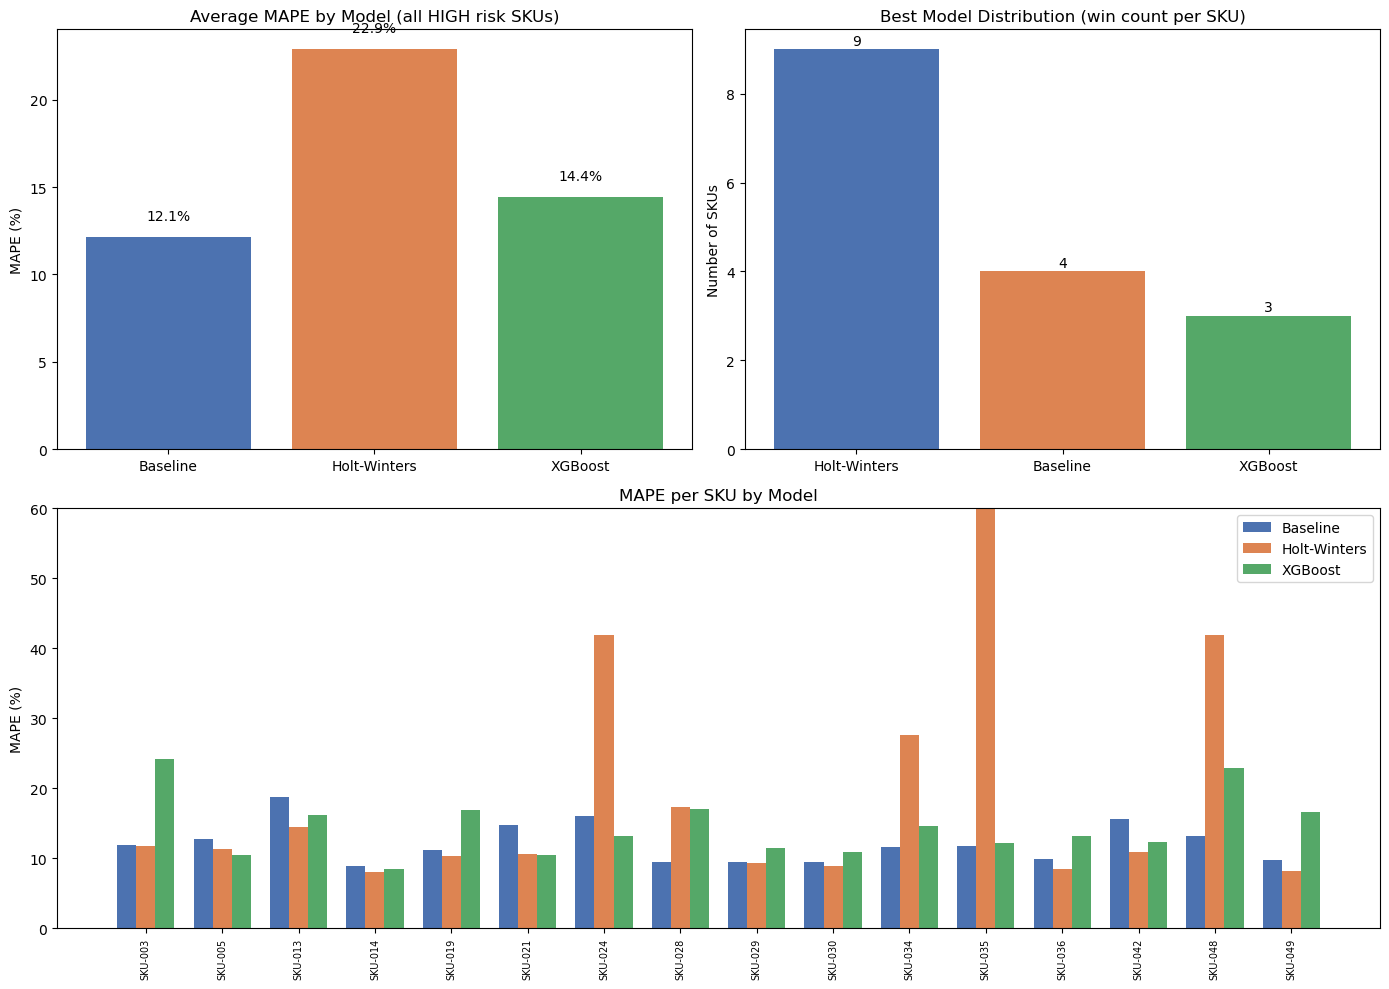

Chart saved to outputs/module4_model_comparison.png


In [8]:
# --- Cell 6 : Visualization ---

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[0, 1])   # top-right
ax3 = fig.add_subplot(gs[1, :])   # bottom, spans both columns

colors = ["#4C72B0", "#DD8452", "#55A868"]

# --- Plot 1 : Average MAPE by model ---
avg_mape = df_comparison[["mape_baseline", "mape_hw", "mape_xgb"]].mean()
ax1.bar(["Baseline", "Holt-Winters", "XGBoost"], avg_mape.values, color=colors)
ax1.set_title("Average MAPE by Model (all HIGH risk SKUs)")
ax1.set_ylabel("MAPE (%)")
for i, v in enumerate(avg_mape.values):
    ax1.text(i, v + 1, f"{v:.1f}%", ha="center")

# --- Plot 2 : Best model distribution ---
best_counts = df_comparison["best_model"].value_counts()
ax2.bar(best_counts.index, best_counts.values, color=colors)
ax2.set_title("Best Model Distribution (win count per SKU)")
ax2.set_ylabel("Number of SKUs")
for i, v in enumerate(best_counts.values):
    ax2.text(i, v + 0.1, str(v), ha="center")

# --- Plot 3 : Per-SKU grouped comparison ---
df_sorted = df_comparison.sort_values("sku_id")
x = np.arange(len(df_sorted))
width = 0.25

ax3.bar(x - width, df_sorted["mape_baseline"], width, label="Baseline", color=colors[0])
ax3.bar(x,         df_sorted["mape_hw"],       width, label="Holt-Winters", color=colors[1])
ax3.bar(x + width, df_sorted["mape_xgb"],      width, label="XGBoost", color=colors[2])

ax3.set_xticks(x)
ax3.set_xticklabels(df_sorted["sku_id"], rotation=90, fontsize=7)
ax3.set_ylabel("MAPE (%)")
ax3.set_title("MAPE per SKU by Model")
ax3.set_ylim(0, 60)
ax3.legend()

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "module4_model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to outputs/module4_model_comparison.png")